In [13]:
import sys
sys.path.append('..')
from scripts.prepare_data import download_data

In [14]:
df = download_data()

In [15]:
# Podstawowe informacje o danych
print(f"Kształt danych: {df.shape}")
print(f"\nTypy kolumn:\n{df.dtypes}")
print(f"\nPodstawowe statystyki:\n{df.describe()}")

Kształt danych: (175729, 34)

Typy kolumn:
record             object
type               object
0_pre-RR            int64
0_post-RR           int64
0_pPeak           float64
0_tPeak           float64
0_rPeak           float64
0_sPeak           float64
0_qPeak           float64
0_qrs_interval      int64
0_pq_interval       int64
0_qt_interval       int64
0_st_interval       int64
0_qrs_morph0      float64
0_qrs_morph1      float64
0_qrs_morph2      float64
0_qrs_morph3      float64
0_qrs_morph4      float64
1_pre-RR            int64
1_post-RR           int64
1_pPeak           float64
1_tPeak           float64
1_rPeak           float64
1_sPeak           float64
1_qPeak           float64
1_qrs_interval      int64
1_pq_interval       int64
1_qt_interval       int64
1_st_interval       int64
1_qrs_morph0      float64
1_qrs_morph1      float64
1_qrs_morph2      float64
1_qrs_morph3      float64
1_qrs_morph4      float64
dtype: object

Podstawowe statystyki:
            0_pre-RR      0_post-RR

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ustawienia wizualizacji
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

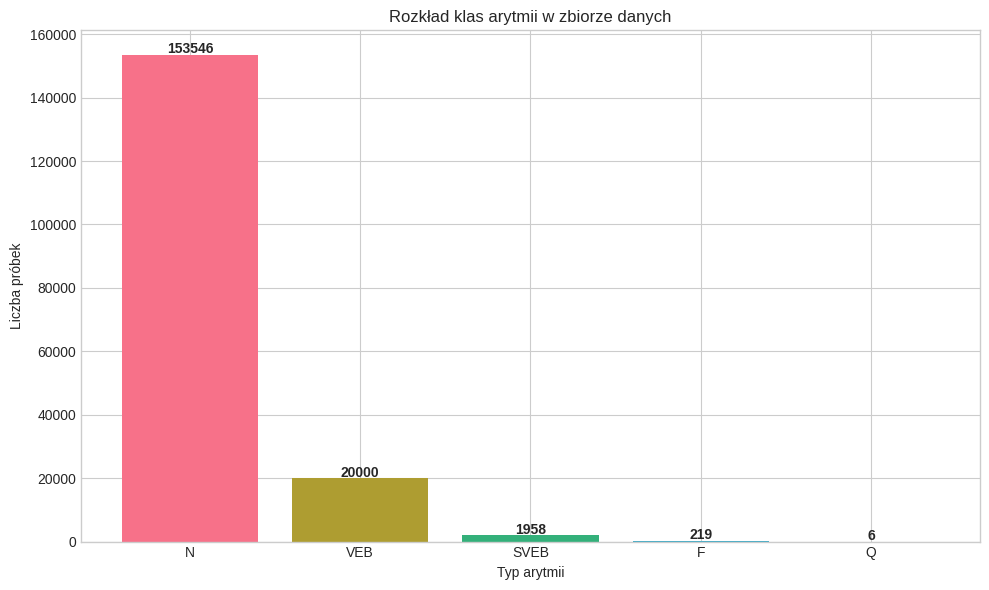

In [17]:
# Rozkład klas arytmii
fig, ax = plt.subplots(figsize=(10, 6))
class_counts = df['type'].value_counts()
ax.bar(class_counts.index, class_counts.values, color=sns.color_palette("husl", len(class_counts)))
ax.set_xlabel('Typ arytmii')
ax.set_ylabel('Liczba próbek')
ax.set_title('Rozkład klas arytmii w zbiorze danych')
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 500, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

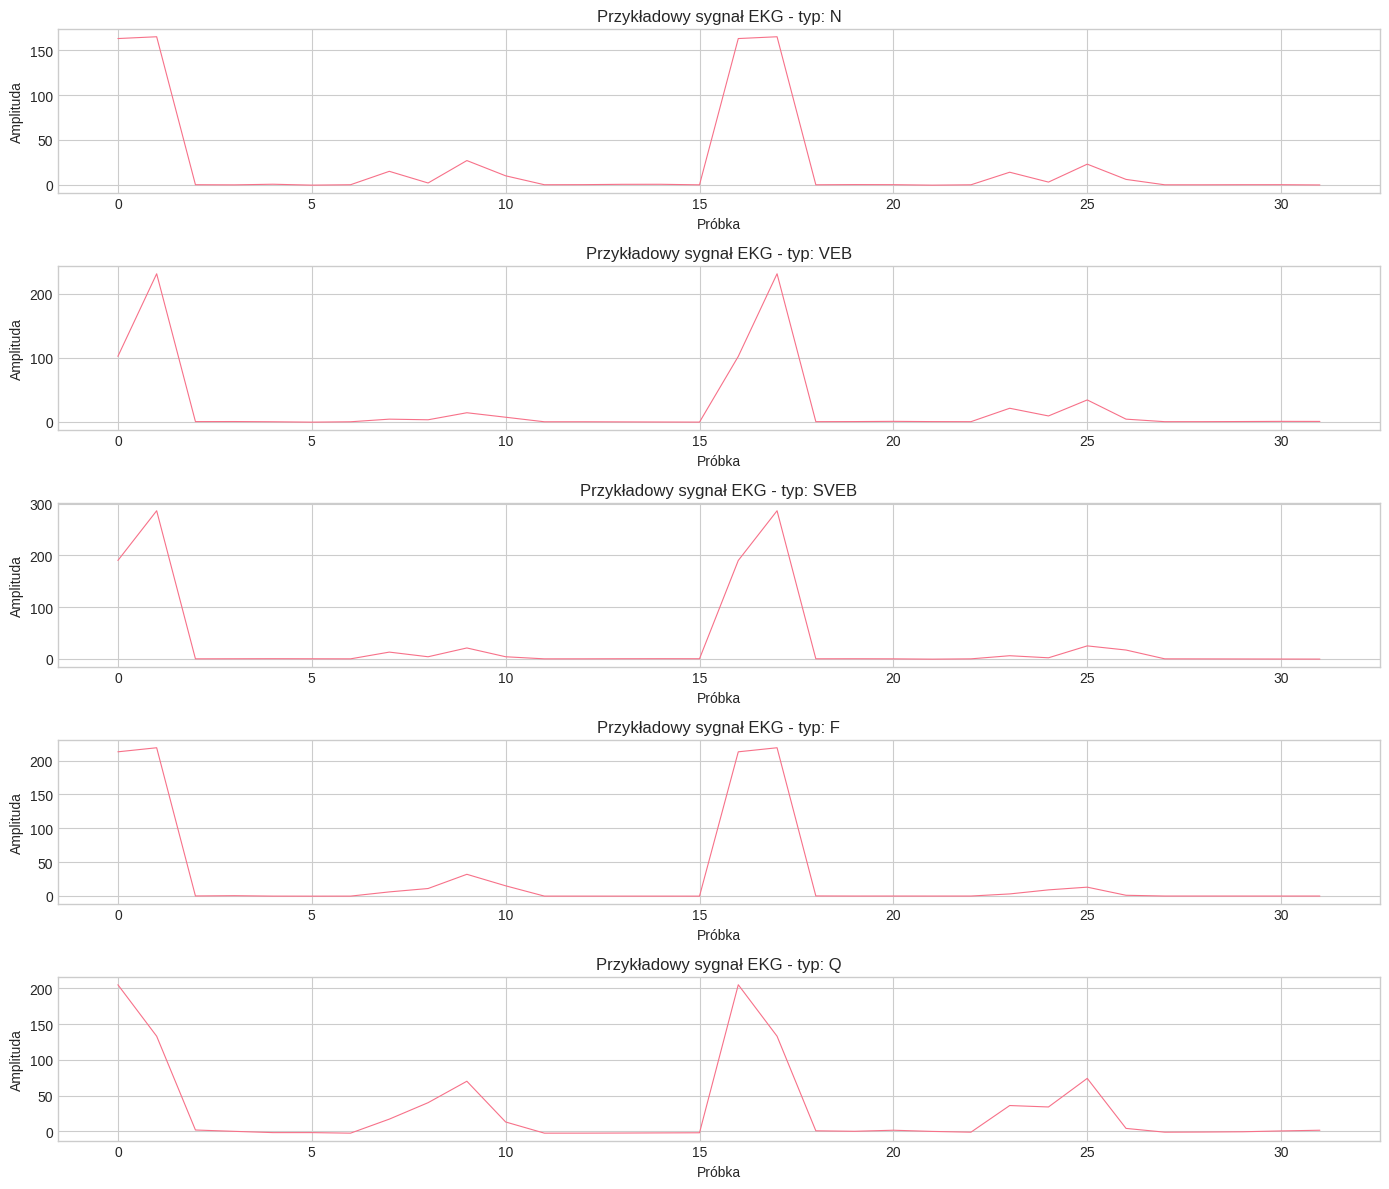

In [18]:
# Przykładowe sygnały EKG dla różnych typów arytmii
# Wybieramy kilka kolumn sygnału (bez 'record' i 'type')
signal_columns = [col for col in df.columns if col not in ['record', 'type']]

fig, axes = plt.subplots(5, 1, figsize=(14, 12))
types = df['type'].unique()

for idx, arrhythmia_type in enumerate(types):
    sample = df[df['type'] == arrhythmia_type].iloc[0]
    signal = sample[signal_columns].values
    axes[idx].plot(signal, linewidth=0.8)
    axes[idx].set_title(f'Przykładowy sygnał EKG - typ: {arrhythmia_type}')
    axes[idx].set_xlabel('Próbka')
    axes[idx].set_ylabel('Amplituda')

plt.tight_layout()
plt.show()

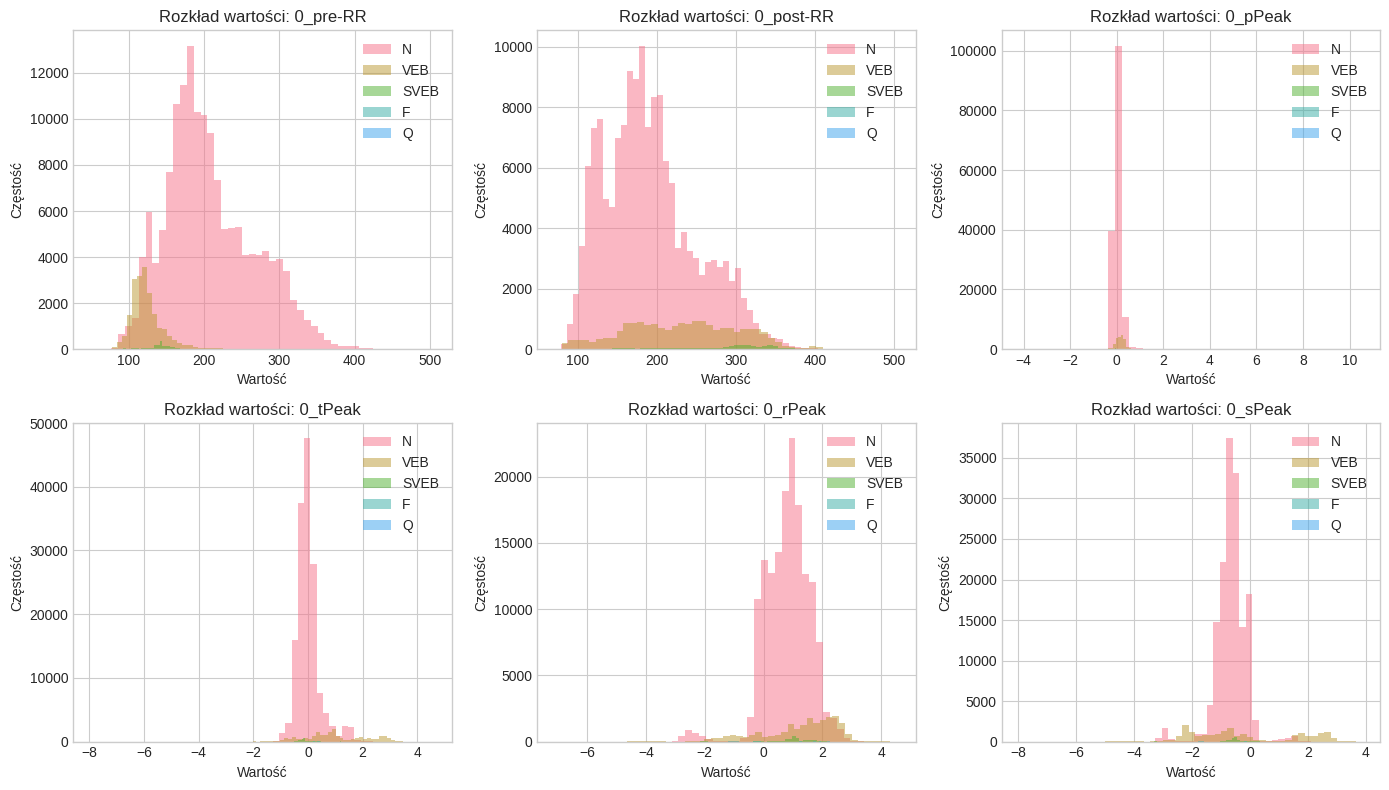

In [19]:
# Histogramy rozkładu wartości dla wybranych cech (pierwszych 6 kolumn sygnału)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, col in enumerate(signal_columns[:6]):
    for arrhythmia_type in df['type'].unique():
        data = df[df['type'] == arrhythmia_type][col]
        axes[idx].hist(data, bins=50, alpha=0.5, label=arrhythmia_type)
    axes[idx].set_title(f'Rozkład wartości: {col}')
    axes[idx].set_xlabel('Wartość')
    axes[idx].set_ylabel('Częstość')
    axes[idx].legend()

plt.tight_layout()
plt.show()

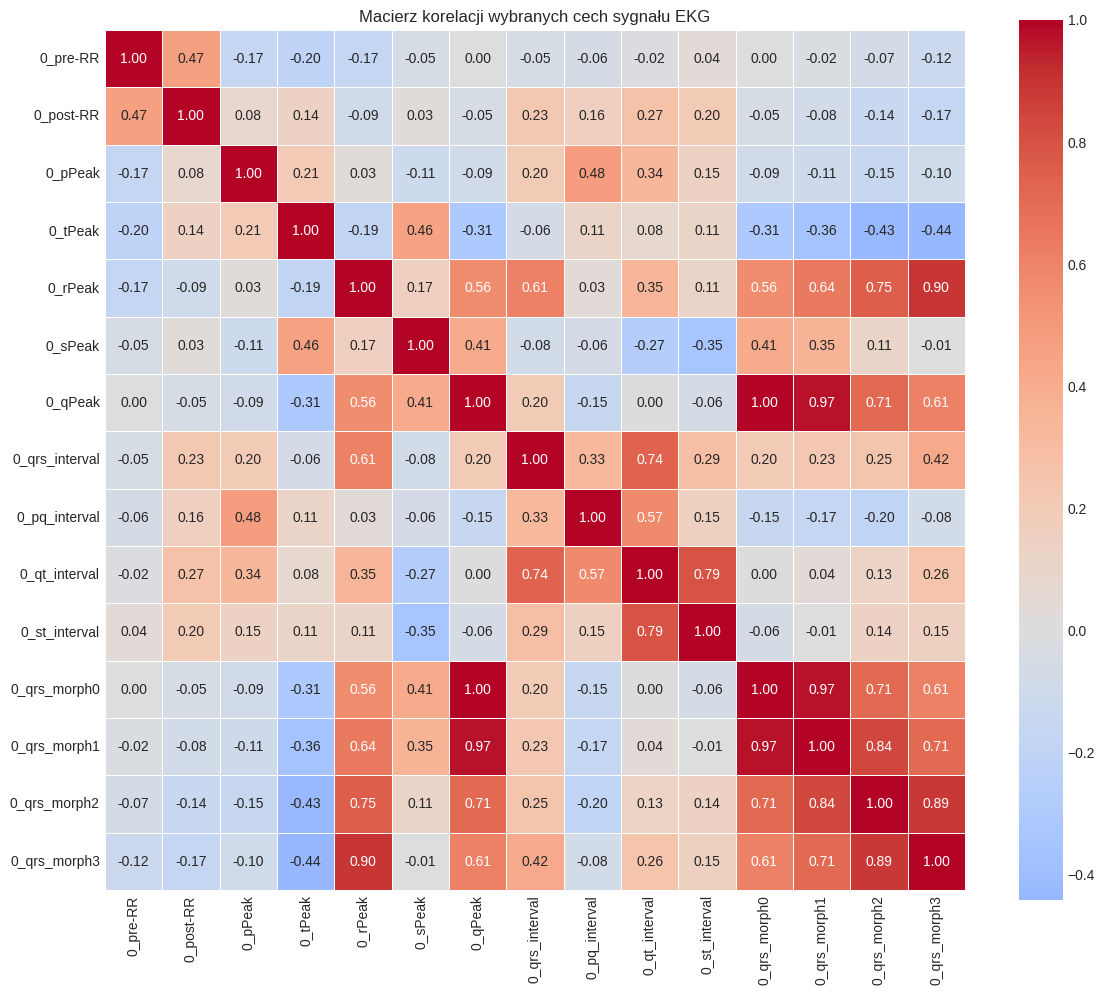

In [20]:
# Macierz korelacji dla wybranych cech
correlation_cols = signal_columns[:15]  # Pierwszych 15 kolumn
correlation_matrix = df[correlation_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', ax=ax, square=True, linewidths=0.5)
ax.set_title('Macierz korelacji wybranych cech sygnału EKG')
plt.tight_layout()
plt.show()

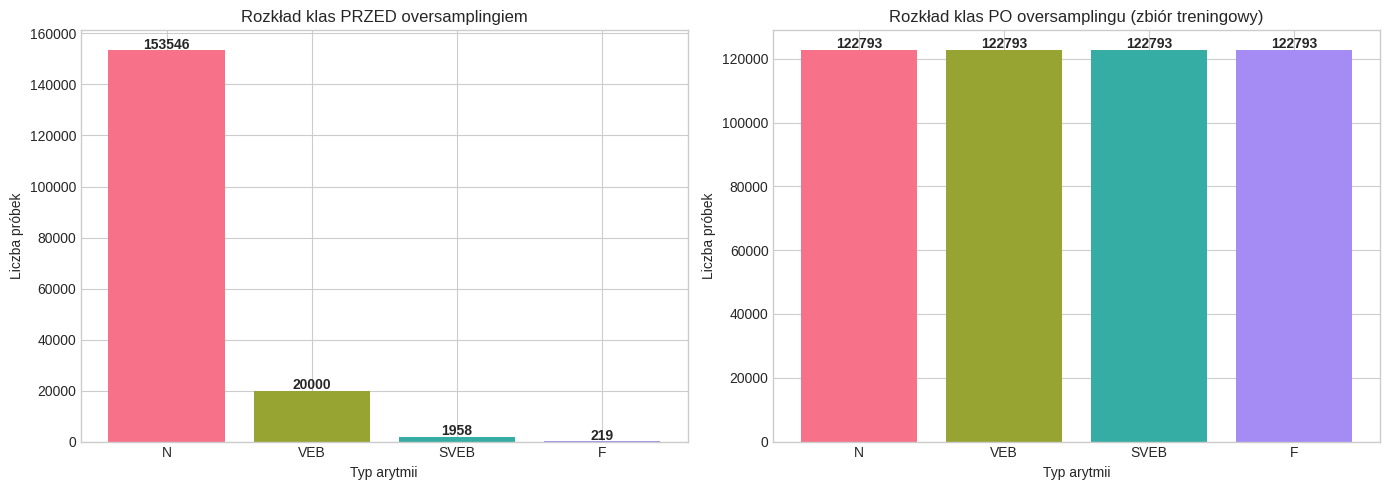


Przed oversamplingiem: 175723 próbek
Po oversamplingu (zbiór treningowy): 736758 próbek


In [21]:
# Porównanie rozkładu klas przed i po oversamplingu
from scripts.prepare_data import preproces_baseline_forest

X_train, X_test, y_train, y_test = preproces_baseline_forest(df)

# Rozkład przed oversamplingiem (oryginalne dane bez klasy Q)
df_no_q = df[df['type'] != 'Q']
original_counts = df_no_q['type'].value_counts()

# Rozkład po oversamplingu
resampled_counts = y_train.value_counts()
type_mapping = {0: 'N', 1: 'VEB', 2: 'SVEB', 3: 'F'}
resampled_counts.index = resampled_counts.index.map(type_mapping)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Przed oversamplingiem
axes[0].bar(original_counts.index, original_counts.values, color=sns.color_palette("husl", len(original_counts)))
axes[0].set_xlabel('Typ arytmii')
axes[0].set_ylabel('Liczba próbek')
axes[0].set_title('Rozkład klas PRZED oversamplingiem')
for i, v in enumerate(original_counts.values):
    axes[0].text(i, v + 500, str(v), ha='center', fontweight='bold')

# Po oversamplingu
axes[1].bar(resampled_counts.index, resampled_counts.values, color=sns.color_palette("husl", len(resampled_counts)))
axes[1].set_xlabel('Typ arytmii')
axes[1].set_ylabel('Liczba próbek')
axes[1].set_title('Rozkład klas PO oversamplingu (zbiór treningowy)')
for i, v in enumerate(resampled_counts.values):
    axes[1].text(i, v + 500, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nPrzed oversamplingiem: {original_counts.sum()} próbek")
print(f"Po oversamplingu (zbiór treningowy): {y_train.sum()} próbek")